# EDA - Dataset de Landmarks de Libras

Dataset gerado a partir do [MINDS-Libras](https://www.kaggle.com/datasets/j0aopsantos/minds-libras) (Kaggle, licença MIT),
extraindo landmarks de pose com o nosso `PoseDetector` (`src/pose_detector.py`) para o Sinalizador01, 20 sinais.

> Execute este notebook a partir da raiz do projeto (`pose-detector/`).

In [1]:
import os
import sys

# garante que a raiz do projeto esteja no path, mesmo se o Jupyter for aberto a partir de notebooks/
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from dataset.schema import carregar_dataset

sns.set_theme(style="whitegrid")

df = carregar_dataset('dataset/dataset.csv')
df.shape

(2970, 101)

## Visão geral

In [2]:
df.head()

,nose_x,nose_y,nose_z,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_x,left_eye_y,left_eye_z,left_eye_outer_x,...,right_heel_y,right_heel_z,left_foot_index_x,left_foot_index_y,left_foot_index_z,right_foot_index_x,right_foot_index_y,right_foot_index_z,video_id,label
0,0.524022,0.383084,-0.567330,0.532838,0.345055,-0.531224,0.539683,0.342901,-0.531407,0.546407,...,1.772516,0.158592,0.626120,1.764760,0.255825,0.539900,1.818151,-0.057148,01AcontecerSinalizador01-1,acontecer
1,0.524136,0.383095,-0.728538,0.533251,0.344982,-0.690327,0.540099,0.342862,-0.690418,0.546765,...,1.845532,0.195960,0.607443,1.828444,0.257586,0.516833,1.901491,-0.033930,01AcontecerSinalizador01-1,acontecer
2,0.524714,0.383029,-0.649419,0.533609,0.344969,-0.596958,0.540313,0.342862,-0.596873,0.546902,...,1.883170,0.189492,0.604680,1.871818,0.391060,0.512042,1.935812,-0.046212,01AcontecerSinalizador01-1,acontecer
3,0.524814,0.387232,-0.643223,0.533666,0.346759,-0.604541,0.540361,0.344399,-0.604661,0.546981,...,1.925615,0.217132,0.594192,1.911426,0.309337,0.497850,1.973080,-0.017916,01AcontecerSinalizador01-1,acontecer
4,0.524836,0.388967,-0.686210,0.533679,0.347469,-0.651289,0.540363,0.345004,-0.651473,0.547002,...,1.943391,0.216573,0.598159,1.937495,0.299521,0.503080,1.988742,-0.024175,01AcontecerSinalizador01-1,acontecer


In [3]:
print('Valores ausentes:', df.isnull().sum().sum())
print('Tipos únicos de coluna:', df.dtypes.unique())

Valores ausentes: 0
Tipos únicos de coluna: [dtype('float64') dtype('O')]


## Distribuição de classes

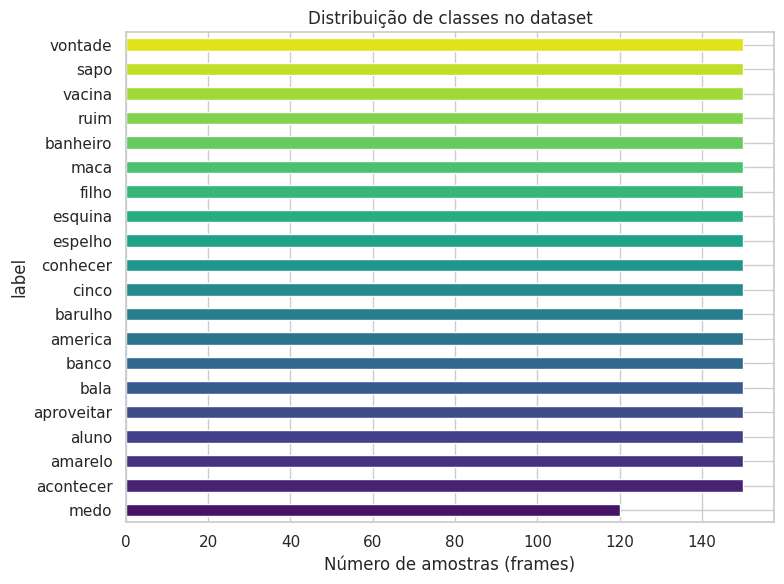

label
medo          120
acontecer     150
amarelo       150
aluno         150
aproveitar    150
bala          150
banco         150
america       150
barulho       150
cinco         150
conhecer      150
espelho       150
esquina       150
filho         150
maca          150
banheiro      150
ruim          150
vacina        150
sapo          150
vontade       150
Name: count, dtype: int64

In [4]:
contagem = df['label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
contagem.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(contagem)))
ax.set_xlabel('Número de amostras (frames)')
ax.set_title('Distribuição de classes no dataset')
plt.tight_layout()
plt.savefig('notebooks/class_distribution.png', dpi=120)
plt.show()

contagem

## Estatísticas descritivas dos landmarks

As coordenadas `x`/`y` do MediaPipe são normalizadas pela imagem (0 a 1); `z` usa o quadril como origem aproximada
e pode ser negativo. Vale conferir se os valores fazem sentido (sem outliers grosseiros, tipo coordenadas fora de [-1, 2]).

In [5]:
features = df.drop(columns=['label', 'video_id'])
resumo = features.describe().T[['min', 'max', 'mean', 'std']]
resumo.loc[['nose_x', 'nose_y', 'nose_z', 'left_wrist_x', 'left_wrist_y', 'left_wrist_z']]

,min,max,mean,std
nose_x,0.435732,0.559037,0.525430,0.015046
nose_y,0.350702,0.403611,0.388980,0.005205
nose_z,-0.836294,-0.104120,-0.642132,0.075886
left_wrist_x,0.465438,0.728138,0.646711,0.042863
left_wrist_y,0.602282,1.161230,1.010090,0.112057
left_wrist_z,-1.021958,0.017106,-0.457971,0.155666


In [6]:
print('Menor valor em todo o dataset:', features.min().min())
print('Maior valor em todo o dataset:', features.max().max())

Menor valor em todo o dataset: -1.2369016408920288
Maior valor em todo o dataset: 2.130825996398926


## Separabilidade das classes (PCA em 2D)

Redução de dimensionalidade só para visualização: se as classes já aparecem razoavelmente separadas em 2D,
é um bom sinal de que um classificador simples (RandomForest/SVM) deve funcionar bem.

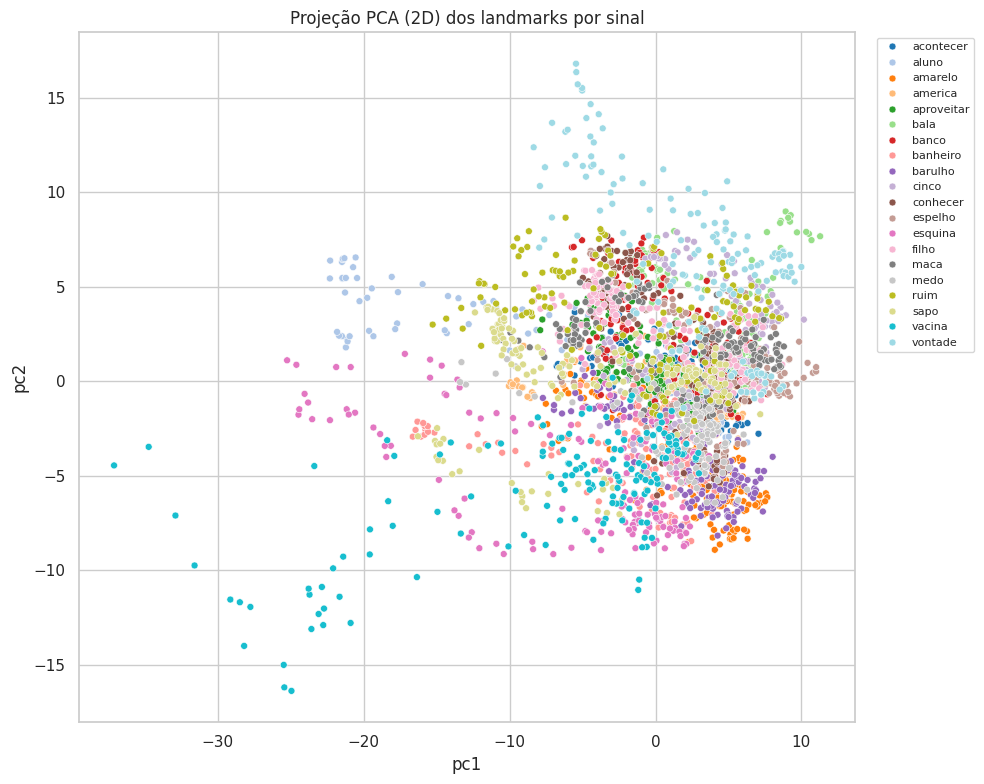

In [7]:
X = StandardScaler().fit_transform(features.values)
componentes = PCA(n_components=2, random_state=42).fit_transform(X)

pca_df = pd.DataFrame(componentes, columns=['pc1', 'pc2'])
pca_df['label'] = df['label'].values

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='pc1', y='pc2', hue='label', palette='tab20', s=25, ax=ax)
ax.set_title('Projeção PCA (2D) dos landmarks por sinal')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('notebooks/pca_projection.png', dpi=120)
plt.show()

## Classificador baseline (RandomForest) e matriz de confusão

Reaproveita `avaliar_com_cv` de `training/train_classifier.py` (mesma validação cruzada agrupada por vídeo
usada no treino "oficial" do modelo) para não duplicar a lógica de avaliação aqui.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from training.train_classifier import avaliar_com_cv

encoder = LabelEncoder()
y = encoder.fit_transform(df['label'].values)
grupos = df['video_id'].values

modelo = RandomForestClassifier(n_estimators=200, random_state=42)
y_pred = avaliar_com_cv(modelo, features.values, y, grupos)

print(classification_report(y, y_pred, target_names=encoder.classes_, zero_division=0))

              precision    recall  f1-score   support

   acontecer       0.74      0.85      0.79       150
       aluno       0.51      0.50      0.51       150
     amarelo       0.62      0.60      0.61       150
     america       0.34      0.21      0.26       150
  aproveitar       0.58      0.73      0.65       150
        bala       0.34      0.49      0.40       150
       banco       0.12      0.10      0.11       150
    banheiro       0.51      0.37      0.43       150
     barulho       0.49      0.73      0.59       150
       cinco       0.36      0.11      0.16       150
    conhecer       0.25      0.26      0.25       150
     espelho       0.58      0.44      0.50       150
     esquina       0.43      0.53      0.48       150
       filho       0.56      0.63      0.59       150
        maca       0.39      0.37      0.38       150
        medo       0.43      0.55      0.49       120
        ruim       0.53      0.45      0.49       150
        sapo       0.50    

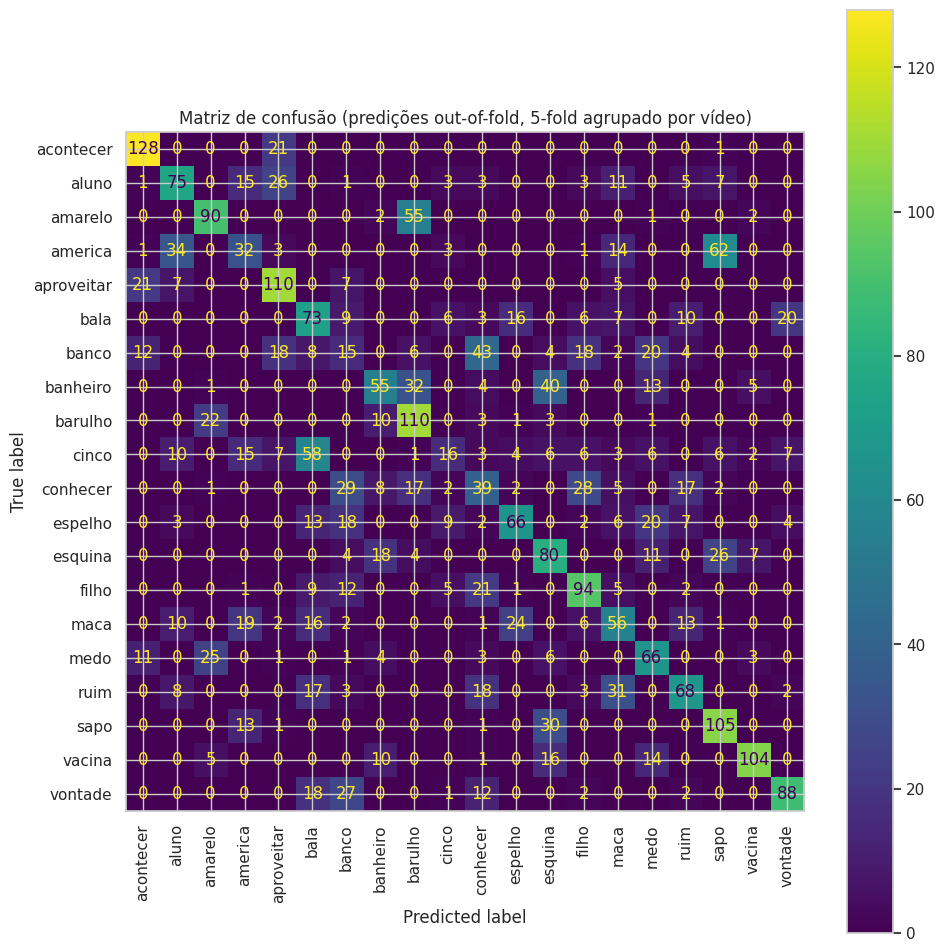

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred, display_labels=encoder.classes_, xticks_rotation=90, ax=ax, cmap='viridis'
)
ax.set_title('Matriz de confusão (predições out-of-fold, 5-fold agrupado por vídeo)')
plt.tight_layout()
plt.savefig('notebooks/confusion_matrix.png', dpi=120)
plt.show()

## Conclusões

- **Sem valores ausentes** e sem outliers absurdos (coordenadas ficam entre -1.24 e 2.13, dentro do esperado para landmarks normalizados do MediaPipe, considerando partes do corpo que saem levemente do quadro).
- **Classes bem balanceadas**: 19 dos 20 sinais têm exatamente 150 amostras (5 vídeos x 30 frames); "medo" tem 120 (faltava 1 vídeo na fonte original no Kaggle). Não foi um problema para o treino.
- **PCA em 2D mostra bastante sobreposição** entre a maioria das classes, com só "aluno", "esquina" e "vacina" formando grupos um pouco mais isolados. Isso é esperado: o `PoseLandmarker` do MediaPipe captura apenas a pose do **corpo** (ombros, cotovelos, pulsos, quadris etc.), sem os pontos finos da **mão** (dedos). Em Libras, boa parte do significado de um sinal está na configuração da mão, não só na posição do braço — então sinais com trajetória de braço parecida mas configuração de mão diferente tendem a se confundir nessa representação.
- **Classificador baseline (RandomForest, validação cruzada agrupada por vídeo): 49% de acurácia em 20 classes** (acaso ≈ 5%) — bem acima do acaso, confirmando que a pose sozinha carrega sinal real, mas moderado. A matriz de confusão mostra pares que se confundem bastante (ex: "banco"/"conhecer", "cinco"/"bala"), consistente com a hipótese de que a distinção depende mais da mão do que do braço nesses casos.
    - Importante: uma primeira tentativa com split aleatório por **frame** (sem agrupar por vídeo) tinha dado 97% de acurácia — número inflado por vazamento de dado, já que frames vizinhos do mesmo vídeo são quase idênticos entre si. Agrupar por `video_id` na validação cruzada corrige isso.
- **Próximo passo natural**: trocar o `PoseLandmarker` pelo `HolisticLandmarker` do MediaPipe (adiciona os 21 pontos de cada mão) deve melhorar bastante a acurácia.